# Gold nanoparticles: which parts of a structure function carry stability?

4000 gold nanoparticles (236 to 14277 atoms), each characterised three
ways as a series on a physical axis:

- the radial distribution function g(r), 500 points over 0.1 to 50 Angstrom,
- the bond angular distribution, 180 one-degree bins,
- the structure factor S(q), 512 points over 0.12 to 31.5 inverse Angstrom,

plus 338 hand-crafted tabular features and one label: total formation
energy. One particle has no label, and RSM's missing-y machinery carries it
without ceremony.

The science question is not "can formation energy be predicted" (it can,
trivially, from size). It is WHICH REGIONS of each characterisation carry
which physics, and RSM answers that with stability frequencies, support,
and honest verdicts attached. The notebook asks it at three levels:

1. total formation energy E (size dominates),
2. energy per atom E/N (surface fraction dominates),
3. the RESIDUAL of E/N after removing the N^(-1/3) surface-fraction trend:
   the excess stability a particle has beyond what its size predicts,
   which is where shape and internal structure live.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

lab = pd.read_csv("Au_label.csv")
feat = pd.read_csv("Au_nanoparticle_features.csv")

def load_series(name):
    df = pd.read_csv(f"Au_nanoparticle_{name}.csv")
    cols = [c for c in df.columns if c != "ID"]
    axis = np.array([float(str(c).split("_")[1]) for c in cols])
    return df[cols].to_numpy(float)[:, None, :], axis

RDF, r_axis = load_series("rdf")
ADF, a_axis = load_series("adf")
SQ, q_axis = load_series("sq")

E = lab["Formation_E"].to_numpy(float)
N = feat["N_total"].to_numpy(float)
ok = ~np.isnan(E)
print(f"{ok.sum()} labelled particles, {int((~ok).sum())} unlabelled")
print(f"corr(E, N) = {np.corrcoef(E[ok], N[ok])[0, 1]:.3f}: size dominates E")

3999 labelled particles, 1 unlabelled
corr(E, N) = 0.906: size dominates E


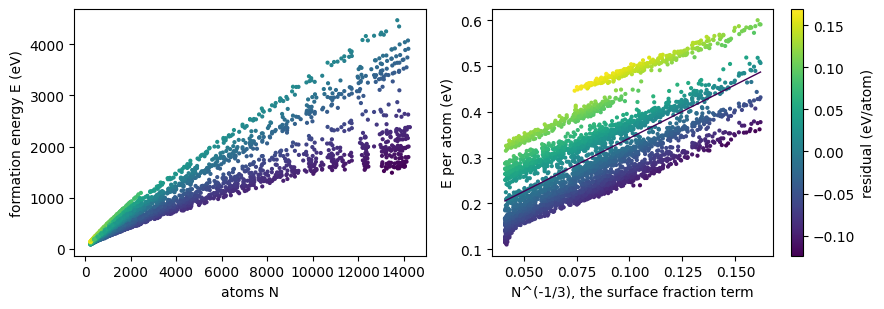

In [2]:
# the three targets: E, E/N, and the size-corrected residual
epa = E / N
size_term = N ** (-1.0 / 3.0)
coef = np.polyfit(size_term[ok], epa[ok], 1)
resid = epa - np.polyval(coef, size_term)
TARGETS = {"E_total": E, "E_per_atom": epa, "E_residual": resid}

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].scatter(N[ok], E[ok], s=4, c=epa[ok], cmap="viridis")
ax[0].set_xlabel("atoms N")
ax[0].set_ylabel("formation energy E (eV)")
sc = ax[1].scatter(size_term[ok], epa[ok], s=4, c=resid[ok], cmap="viridis")
xs = np.linspace(size_term[ok].min(), size_term[ok].max(), 50)
ax[1].plot(xs, np.polyval(coef, xs), color=plt.cm.viridis(0.0), lw=1)
ax[1].set_xlabel("N^(-1/3), the surface fraction term")
ax[1].set_ylabel("E per atom (eV)")
fig.colorbar(sc, ax=ax[1], label="residual (eV/atom)")
plt.tight_layout()

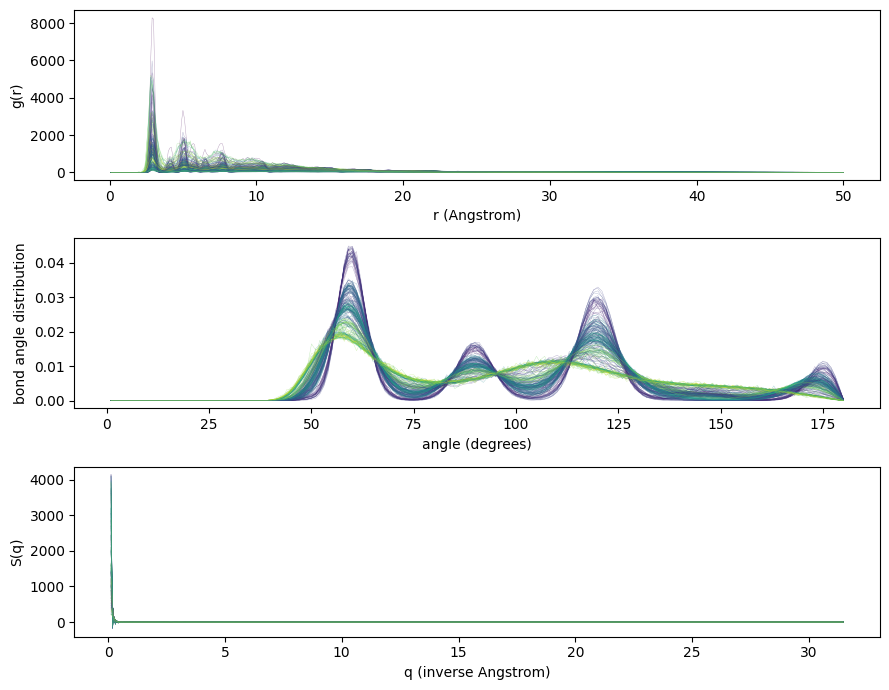

In [3]:
# the three characterisations, coloured by excess stability (viridis)
fig, axes = plt.subplots(3, 1, figsize=(9, 7))
span = np.nanmax(resid) - np.nanmin(resid)
shade = plt.cm.viridis((resid - np.nanmin(resid)) / span)
sub = np.random.default_rng(0).choice(np.flatnonzero(ok), 250, replace=False)
for ax, (Xs, axis, name, xl) in zip(axes, [
        (RDF, r_axis, "g(r)", "r (Angstrom)"),
        (ADF, a_axis, "bond angle distribution", "angle (degrees)"),
        (SQ, q_axis, "S(q)", "q (inverse Angstrom)")]):
    for i in sub:
        ax.plot(axis, Xs[i, 0], color=shade[i], lw=0.3, alpha=0.4)
    ax.set_ylabel(name)
    ax.set_xlabel(xl)
plt.tight_layout()

## Reference points before any band selection

Ridge regression, 5-fold CV R2. Size alone explains 82% of E and none of
the residual (by construction); the 338 tabular features explain 98% of E
and, notably, 77% of the residual: the excess stability is real,
predictable structure signal, not noise.

In [4]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def ridge_r2(F, yv, seed=0):
    m = ~np.isnan(yv)
    model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    cv = KFold(n_splits=5, shuffle=True, random_state=seed)
    return r2_score(yv[m], cross_val_predict(model, F[m], yv[m], cv=cv))

TAB = feat[[c for c in feat.columns if c != "ID"]].to_numpy(float)
for t, yv in TARGETS.items():
    print(f"{t:12s} N alone: {ridge_r2(N[:, None], yv):6.3f}   "
          f"tabular 338: {ridge_r2(TAB, yv):6.3f}")

E_total      N alone:  0.820   tabular 338:  0.984


E_per_atom   N alone:  0.326   tabular 338:  0.863


E_residual   N alone:  0.000   tabular 338:  0.775


## RSM across three characterisations and three questions

Segments of 2 Angstrom (g(r)), 10 degrees (angles), and about 0.9 inverse
Angstrom (S(q)); a five-band budget everywhere, so every comparison is at
comparable coverage (a frequency tie at the chosen threshold occasionally
admits a sixth band). About half a minute per cell entry; roughly five
minutes for the grid.

In [5]:
from robustsignalmaker import BootstrapMaskSelector, SegmentGrid

MODS = {"rdf": (RDF, r_axis, 20), "adf": (ADF, a_axis, 10), "sq": (SQ, q_axis, 16)}
runs = {}
for mname, (X, axis, seg) in MODS.items():
    grid = SegmentGrid(X.shape[-1], segment=seg)
    F_seg = X[:, 0, :].reshape(len(X), grid.n_segments, -1).mean(axis=2)
    for tname, yv in TARGETS.items():
        m = ~np.isnan(yv)
        sel = BootstrapMaskSelector(task="regression", segment=seg,
                                    lam=0.08, n_iter=300, lr=0.1,
                                    n_bootstrap=30, target_coverage=5 / grid.n_segments,
                                    seed=0).fit(X[m], yv[m])
        chosen = sel.selected_segments_
        runs[(mname, tname)] = (sel, grid, axis)
        bands = [f"{axis[grid.segments_to_points([s])[0]]:.1f}-"
                 f"{axis[grid.segments_to_points([s])[-1]]:.1f}" for s in chosen]
        print(f"{mname:4s} {tname:11s} R2(5 bands)={ridge_r2(F_seg[:, chosen], yv):5.2f} "
          f"R2(full)={ridge_r2(F_seg, yv):5.2f}  bands: {bands}")

rdf  E_total     R2(5 bands)= 0.82 R2(full)= 0.84  bands: ['4.1-6.0', '6.1-8.0', '16.1-18.0', '20.1-22.0', '48.1-50.0']


rdf  E_per_atom  R2(5 bands)= 0.51 R2(full)= 0.72  bands: ['8.1-10.0', '18.1-20.0', '22.1-24.0', '24.1-26.0', '26.1-28.0']


rdf  E_residual  R2(5 bands)= 0.39 R2(full)= 0.48  bands: ['4.1-6.0', '6.1-8.0', '8.1-10.0', '16.1-18.0', '18.1-20.0']


adf  E_total     R2(5 bands)= 0.60 R2(full)= 0.61  bands: ['41.0-50.0', '51.0-60.0', '61.0-70.0', '111.0-120.0', '121.0-130.0', '161.0-170.0']


adf  E_per_atom  R2(5 bands)= 0.84 R2(full)= 0.90  bands: ['41.0-50.0', '51.0-60.0', '61.0-70.0', '71.0-80.0', '141.0-150.0']


adf  E_residual  R2(5 bands)= 0.73 R2(full)= 0.84  bands: ['41.0-50.0', '51.0-60.0', '61.0-70.0', '81.0-90.0']


sq   E_total     R2(5 bands)= 0.91 R2(full)= 0.93  bands: ['0.1-1.0', '1.1-2.0', '2.1-3.0', '3.1-4.0', '7.0-7.9']


sq   E_per_atom  R2(5 bands)= 0.86 R2(full)= 0.90  bands: ['0.1-1.0', '2.1-3.0', '8.0-8.9', '9.0-9.9', '9.9-10.9']


sq   E_residual  R2(5 bands)= 0.80 R2(full)= 0.83  bands: ['3.1-4.0', '6.0-6.9', '8.0-8.9', '9.0-9.9', '9.9-10.9', '12.9-13.8']


## Reading the grid: the modality ladder inverts with the question

From the measured run (benchmarks/FINDINGS.md sec.7 records it):

- **E_total**: S(q) wins (R2 0.91 from five bands), and its bands are the
  LOW-q region (four of its five bands sit below q = 4, the form-factor
  regime that encodes particle size; the fifth sits near q = 7). g(r) matches size-alone (0.82). The angular distribution fails
  (0.60), and it should: bond angles are size-blind.
- **E_per_atom**: the ladder reorders. The angle distribution climbs from
  worst to near-best (R2 0.84 from five 10-degree bands, against S(q)'s
  0.86, having trailed it by 0.31 on E), because per-atom stability is
  surface and motif physics rather than size.
- **E_residual**: with size fully removed, S(q) and the angles carry
  nearly everything the 338 tabular features carry (0.80 and 0.73 vs
  0.77), from five or six bands of one measured curve.

And the bands are legible physics:

- the residual-stability ANGLE window is 41 to 90 degrees, covering the FCC
  60 and 90 degree signatures and the 63 degree five-fold twin angle (72
  degrees falls just outside it);
- g(r)'s residual bands are MEDIUM-RANGE order (4 to 10 and 16 to 20
  Angstrom), not the first shell near 2.9 Angstrom, which every gold
  particle shares; stability differences live in how shells stack, not in
  the bond length;
- S(q)'s E_per_atom bands include the Au Bragg (111) region near
  q = 2.7, and its residual bands sit in the high-q diffraction detail.

In [6]:
# the honesty layer, on real data: angles below 31 degrees do not exist in
# this dataset (no such bond angles), and RSM says so rather than rejecting
sel_adf, grid_adf, _ = runs[("adf", "E_residual")]
print("ADF verdicts, segments 0-3:", sel_adf.verdicts_[:4].tolist())
print("pi of those segments:", sel_adf.pi_[:4])
print("an unmeasured region is UNASSESSABLE, never 'stably rejected'")

ADF verdicts, segments 0-3: ['unassessable', 'unassessable', 'unassessable', 'rejected']
pi of those segments: [nan nan nan  0.]
an unmeasured region is UNASSESSABLE, never 'stably rejected'


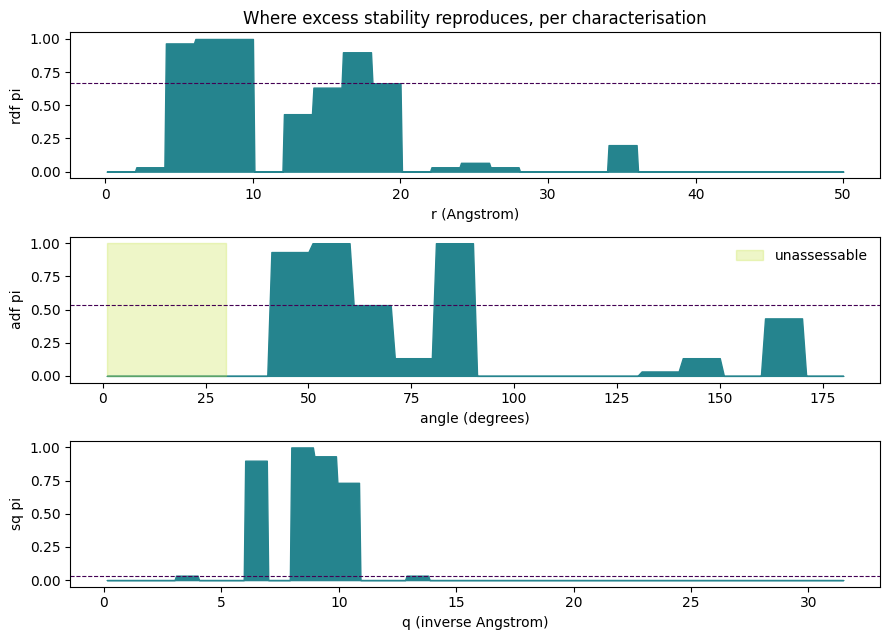

In [7]:
# stability maps side by side for the residual question
fig, axes = plt.subplots(3, 1, figsize=(9, 6.5))
for ax, mname, xl in zip(axes, ("rdf", "adf", "sq"),
                          ("r (Angstrom)", "angle (degrees)", "q (inverse Angstrom)")):
    sel, grid, axis = runs[(mname, "E_residual")]
    ax.fill_between(axis, 0, np.nan_to_num(sel.pi_points()),
                    color=plt.cm.viridis(0.45))
    unob = np.isnan(sel.pi_points())
    if unob.any():
        ax.fill_between(axis, 0, 1, where=unob, color=plt.cm.viridis(0.9),
                        alpha=0.25, label="unassessable")
        ax.legend(frameon=False)
    ax.axhline(sel.tau_, color=plt.cm.viridis(0.0), lw=0.8, ls="--")
    ax.set_ylabel(f"{mname} pi")
    ax.set_xlabel(xl)
axes[0].set_title("Where excess stability reproduces, per characterisation")
plt.tight_layout()

## Does the answer depend on the lens?

Measured agreement between the lenses on the residual question, for the
bond-angle curve below, is 0.25: genuinely lens-dependent, the
regime where marginalising over the ensemble is the defensible report
rather than a luxury (compare benchmarks/FINDINGS.md sec.6, corn).

In [8]:
from robustsignalmaker import RepresentationEnsembleSelector, default_ensemble

m = ~np.isnan(resid)
ens = RepresentationEnsembleSelector(
    representations=default_ensemble(3, seed=0), task="regression",
    segment=10, lam=0.08, n_iter=250, lr=0.1, n_bootstrap=10,
    target_coverage=5 / 18, seed=0).fit(ADF[m], resid[m])
print("lens agreement:", round(float(ens.representation_agreement()), 2))
print("marginalised angle bands:",
      [f"{a_axis[ens.grid.segments_to_points([s])[0]]:.0f}-"
       f"{a_axis[ens.grid.segments_to_points([s])[-1]]:.0f} deg"
       for s in ens.selected_segments_])

lens agreement: 0.25
marginalised angle bands: ['31-40 deg', '51-60 deg', '61-70 deg', '81-90 deg']


## The honest verdict, nested

Everything above was selection on the full data; the claim needs nested
CV. Headline case: angles predicting excess stability. The unlabelled
particle is excluded and counted, the same four angle bands are selected
in every fold, and the verdict is `preserved`, with the 5-fold caveat from
the interpretation guide (the Wilcoxon floor at K=5 is 0.0625, and the
full signal was slightly ahead on every fold, so read `preserved` as
"nothing significant lost at 22% coverage", not "nothing lost").

In [9]:
from robustsignalmaker import NestedCV

res = NestedCV(k_outer=5, segment=10, lam=0.08, n_bootstrap=20,
               target_coverage=5 / 18, mnar_guard=False,
               random_state=0).run(ADF, resid)
s = res.summary()
{k: s[k] for k in ("score_name", "score_mean", "baseline_score_mean",
                    "verdict", "verdict_p_wilcoxon",
                    "selection_stability_adjusted", "mean_n_selected",
                    "n_unlabelled_excluded")}

{'score_name': 'RMSE',
 'score_mean': 0.029655226922671314,
 'baseline_score_mean': 0.027886505632764756,
 'verdict': 'preserved',
 'verdict_p_wilcoxon': 0.0625,
 'selection_stability_adjusted': 1.0,
 'mean_n_selected': 4.0,
 'n_unlabelled_excluded': 1}

## Motif classification: FCC versus twinned or disordered interiors

The energy questions were regression; the motif question is the natural
classification. No explicit motif label ships with the data, so one is
DERIVED, transparently, from the Steinhardt q6q6 bond-order analysis in the
tabular features: `q6q6_avg_bulk` counts crystalline connections per
interior atom and is strongly bimodal (a mode near 0 to 2 and a mode near
11 to 12, against the 12 nearest neighbours of a bulk FCC site), so a mid-valley threshold at 6
splits FCC-ordered interiors from twinned or disordered ones. Two honesty
notes: the label comes from coordinate-space bond-order analysis, a channel
independent of the three curves being selected on, so there is no
circularity; and the split is threshold-robust (the FCC fraction moves only
0.70 to 0.74 as the threshold sweeps 4 to 8).

FCC-ordered: 2884   twinned/disordered: 1116
  threshold 4.0: FCC fraction 0.737
  threshold 6.0: FCC fraction 0.721
  threshold 8.0: FCC fraction 0.698


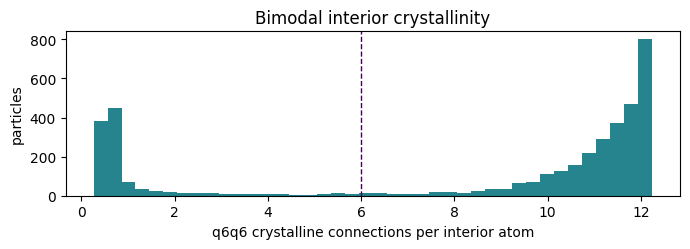

In [10]:
q6b = feat["q6q6_avg_bulk"].to_numpy(float)
motif = (q6b >= 6.0).astype(int)  # 1 = FCC-ordered interior
print(f"FCC-ordered: {int(motif.sum())}   twinned/disordered: {int((1 - motif).sum())}")
for thr in (4.0, 6.0, 8.0):
    print(f"  threshold {thr}: FCC fraction {float((q6b >= thr).mean()):.3f}")

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.hist(q6b, bins=40, color=plt.cm.viridis(0.45))
ax.axvline(6.0, color=plt.cm.viridis(0.0), lw=1, ls="--")
ax.set_xlabel("q6q6 crystalline connections per interior atom")
ax.set_ylabel("particles")
ax.set_title("Bimodal interior crystallinity")
plt.tight_layout()

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

def logit_auc(F, yv, seed=0):
    model = make_pipeline(StandardScaler(),
                          LogisticRegression(max_iter=1000, random_state=seed))
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    proba = cross_val_predict(model, F, yv, cv=cv, method="predict_proba")
    return roc_auc_score(yv, proba[:, 1])

motif_runs = {}
for mname, (X, axis, seg) in MODS.items():
    grid = SegmentGrid(X.shape[-1], segment=seg)
    F_seg = X[:, 0, :].reshape(len(X), grid.n_segments, -1).mean(axis=2)
    sel = BootstrapMaskSelector(task="binary", segment=seg, lam=0.08,
                                n_iter=300, lr=0.1, n_bootstrap=30,
                                target_coverage=5 / grid.n_segments,
                                seed=0).fit(X, motif)
    motif_runs[mname] = (sel, grid, axis)
    ch = sel.selected_segments_
    bands = [f"{axis[grid.segments_to_points([s])[0]]:.1f}-"
             f"{axis[grid.segments_to_points([s])[-1]]:.1f}" for s in ch]
    print(f"{mname:4s} AUC(selected)={logit_auc(F_seg[:, ch], motif):.3f} "
          f"AUC(full)={logit_auc(F_seg, motif):.3f}  bands: {bands}")

rdf  AUC(selected)=0.965 AUC(full)=0.969  bands: ['6.1-8.0', '8.1-10.0', '16.1-18.0', '24.1-26.0', '26.1-28.0']


adf  AUC(selected)=1.000 AUC(full)=1.000  bands: ['81.0-90.0', '101.0-110.0', '121.0-130.0', '151.0-160.0']


sq   AUC(selected)=0.999 AUC(full)=0.999  bands: ['3.1-4.0', '4.0-5.0', '5.0-6.0', '6.0-6.9', '8.0-8.9']


From the measured run: the angle distribution separates the motifs
PERFECTLY (AUC 1.000) from four 10-degree bands, and which bands is the
point: 81 to 90, 101 to 110, 121 to 130 and 151 to 160 degrees, the FCC 90,
tetrahedral 109.5, and (just above) the 120 degree signatures, and
pointedly NOT the 60
degree band, because both motifs have close-packed first shells and 60
degree triangles; the discriminating information is where FCC order does
something twinned interiors do not. S(q) reaches AUC 0.999 from the
Bragg-reflection region (q between 3 and 9) while IGNORING the low-q
form-factor region it used for total energy: motif is size-independent and
the selection reflects that without being told. g(r) manages 0.965 from
medium-range order. The nested verdict (below) selects the same four angle
bands in every fold.

In [12]:
res_motif = NestedCV(k_outer=5, segment=10, lam=0.08, n_bootstrap=20,
                     target_coverage=5 / 18, mnar_guard=False,
                     random_state=0).run(ADF, motif)
sm = res_motif.summary()
{k: sm[k] for k in ("score_name", "score_mean", "baseline_score_mean",
                     "verdict", "selection_stability_adjusted",
                     "mean_n_selected")}

{'score_name': 'AUC',
 'score_mean': 0.9999238707826951,
 'baseline_score_mean': 0.9999782560852101,
 'verdict': 'preserved',
 'selection_stability_adjusted': 1.0,
 'mean_n_selected': 4.0}

## What this shows

One dataset, three characterisations, four physical questions, and RSM
returns range-level answers with reproducibility and honesty attached:
size lives at low q, per-atom stability in the bond-angle motif window,
excess stability in medium-range order and diffraction detail, and the
FCC-versus-twinned distinction in exactly the angle bands where FCC order
exists and twinned interiors differ (90, 109.5, 120 degrees), classified
perfectly while ignoring the size information the energy questions needed.
Five or six bands of a measured curve rival 338 hand-crafted features on
the residual (the budget targets five; a frequency tie at the threshold
sometimes admits a sixth); unmeasured angle regions report as
unassessable; the unlabelled particle is counted, not silently dropped;
and the selected bands survive nested cross-validation unchanged for both
the energy and the motif questions. The one-line report template is
INTERPRETATION_GUIDE section 11.